<a href="https://colab.research.google.com/github/luisffarias-dev/ML_Previsao_de_Performace/blob/main/Previsao_de_perfomace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Matéria: Aprendizado de Máquina




Professor: Bruno Zolotareff dos Santos

Ano: 2026

Nomes: Luis Fernando França Farias;
Luis Felipe Sousa Foresto;
Ryan Pereira da Mota;
Kauã da Silva Augusto;
Lucas Casagrande Silva

Bibliotecas que serão utilizadas para o algoritmo

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

Upload do dataset

In [3]:
from google.colab import files

uploaded = files.upload()

Saving student-mat.csv to student-mat (1).csv


In [4]:
import os

os.listdir('/content')

['.config', 'student-mat.csv', 'student-mat (1).csv', 'sample_data']

Carregando o dataset

In [5]:
df = pd.read_csv('student-mat.csv', sep=';')

df.head()



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [19]:
df.shape

(395, 43)

Pré-processamento: Criação do Alvo (Aprovado) e Dummies


In [39]:
# Cria a coluna 'Aprovado' ANTES do get_dummies para ela não se perder
df['Aprovado'] = (df['G3'] >= 10).astype(int)


df = pd.get_dummies(df, drop_first=True)

df.shape

(395, 43)

In [37]:
df.describe()





,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Aprovado
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000,1.000000


Análise exploratoria

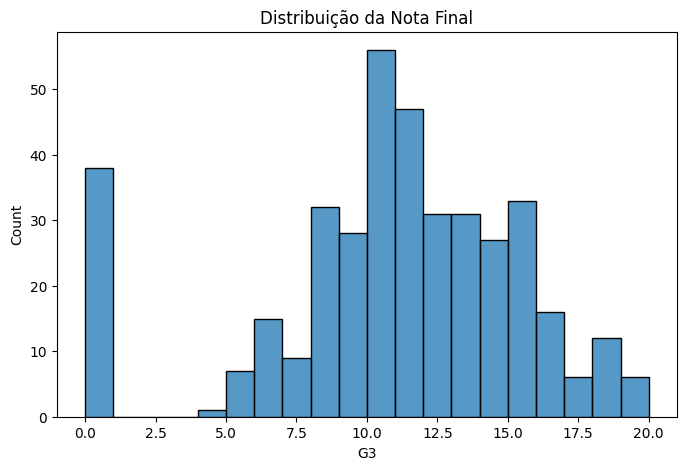

In [9]:
# Gráfico de distribuição da nota final
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20)
plt.title('Distribuição da Nota Final')
plt.show()

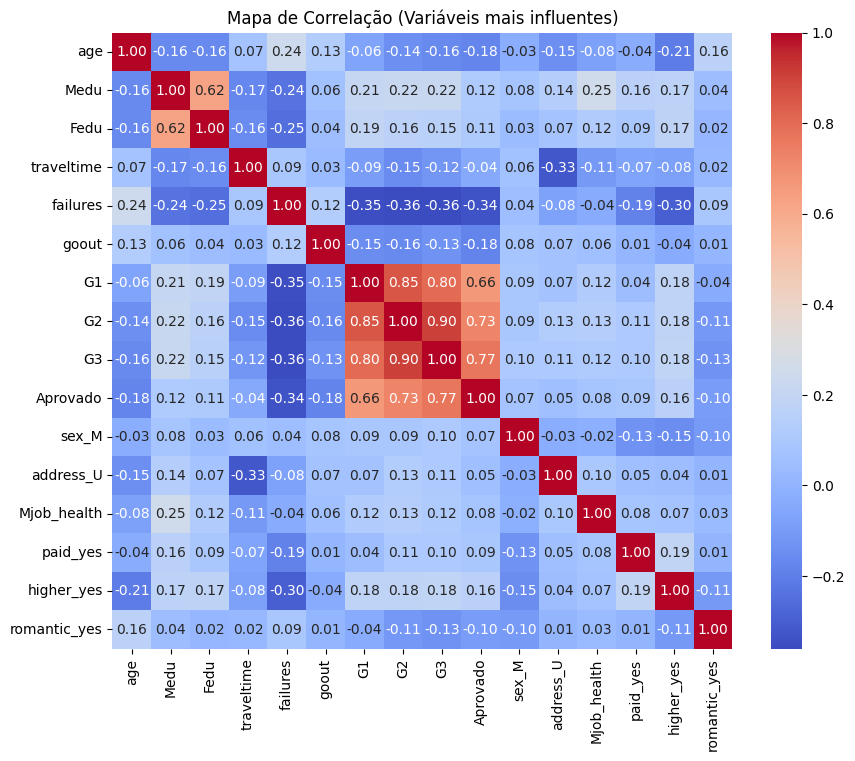

In [10]:
# Mapa de Calor filtrado (mostra apenas variáveis com maior impacto na nota G3)
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
top_corr_features = corr.index[abs(corr["G3"]) > 0.1] # Pega correlações maiores que 10%
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlação (Variáveis mais influentes)')
plt.show()

PARTE 1: MODELO DE REGRESSÃO (Prevendo a nota exata)

In [40]:
# Dropamos G1, G2 e Aprovado para o modelo não "colar" das provas anteriores
X_reg = df.drop(['G3', 'G1', 'G2', 'Aprovado'], axis=1)
y_reg = df['G3']

# Divisão de Treino e Teste
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Treinamento do Modelo de Regressão
modelo_reg = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_reg.fit(X_train_reg, y_train_reg)

# Previsões
y_pred_reg = modelo_reg.predict(X_test_reg)

Avaliação da Regressão e Importância das Variáveis

Métricas da Regressão:
MAE: 3.081772151898734
RMSE: 3.868963734612517
R²: 0.2699904475197701


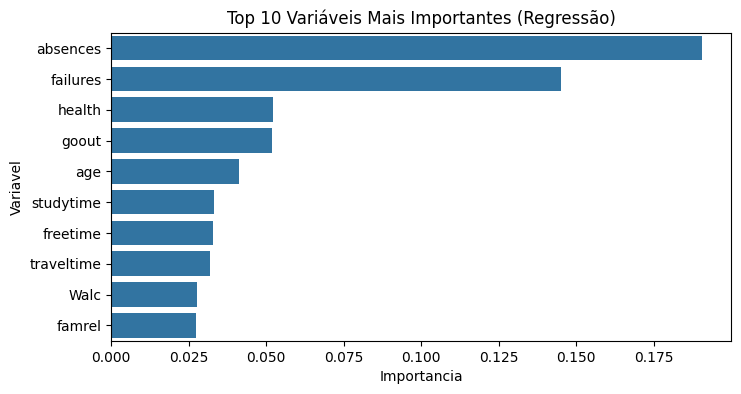

In [50]:
print("Métricas da Regressão:")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("R²:", r2_score(y_test_reg, y_pred_reg))

# Importância das variáveis no modelo de regressão
importances = pd.DataFrame({
    'Variavel': X_reg.columns,
    'Importancia': modelo_reg.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=importances.head(10), x='Importancia', y='Variavel')
plt.title('Top 10 Variáveis Mais Importantes (Regressão)')
plt.show()

PARTE 2: MODELO DE CLASSIFICAÇÃO (Calculando Risco de Reprovação)

In [51]:
# Definindo novo alvo (Aprovado/Reprovado)
X_class = df.drop(['G3', 'G1', 'G2', 'Aprovado'], axis=1)
y_class = df['Aprovado']

# Divisão de Treino e Teste
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Treinamento do Classificador
modelo_class = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_class.fit(X_train_class, y_train_class)

# Previsões "Secas" (Apenas 0 ou 1)
y_pred_class = modelo_class.predict(X_test_class)


# Verificando como os dados foram divididos
print(f"Tamanho do conjunto de Treino: {len(X_train_class)} alunos")
print(f"Tamanho do conjunto de Teste: {len(X_test_class)} alunos")

# Mostrando as 10 primeiras previsões secas geradas pelo modelo
print("\nPrimeiras 10 previsões do modelo (0 = Reprovou, 1 = Passou):")
print(y_pred_class[:10])

Tamanho do conjunto de Treino: 316 alunos
Tamanho do conjunto de Teste: 79 alunos

Primeiras 10 previsões do modelo (0 = Reprovou, 1 = Passou):
[1 1 1 1 1 1 1 0 1 1]


Análise de Risco (Probabilidades) e Avaliação do Modelo

=== TABELA DE ANÁLISE DE RISCO (10 primeiros alunos testados) ===
  Situação Real Previsão do Algoritmo  Risco de Reprovar (%)  \
0      Aprovado              Aprovado                   44.0   
1     Reprovado              Aprovado                   46.5   
2      Aprovado              Aprovado                   42.5   
3      Aprovado              Aprovado                   32.5   
4      Aprovado              Aprovado                   20.0   
5      Aprovado              Aprovado                   29.0   
6      Aprovado              Aprovado                   23.0   
7     Reprovado             Reprovado                   53.0   
8      Aprovado              Aprovado                   26.5   
9      Aprovado              Aprovado                   16.5   

   Chance de Aprovar (%)  
0                   56.0  
1                   53.5  
2                   57.5  
3                   67.5  
4                   80.0  
5                   71.0  
6                   77.0  
7            

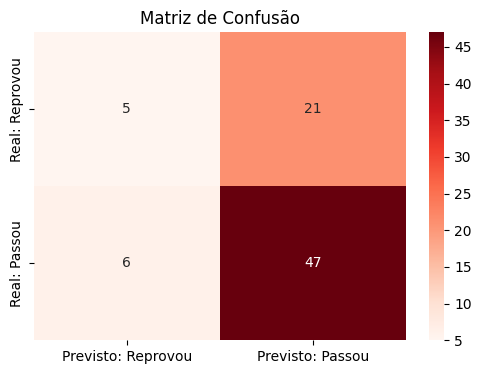

In [52]:
# 1. CALCULANDO AS PROBABILIDADES
# O predict_proba retorna uma matriz com duas colunas: [chance_de_0, chance_de_1]
probabilidades = modelo_class.predict_proba(X_test_class)

# Pegamos a coluna 0 (chance de ser 0 = Reprovar) e multiplicamos por 100 para virar %
chance_reprovar = probabilidades[:, 0] * 100
chance_aprovar = probabilidades[:, 1] * 100

# 2. MONTANDO A TABELA DE ANÁLISE DE RISCO
analise_risco = pd.DataFrame({
    'Situação Real': y_test_class.values,
    'Previsão do Algoritmo': y_pred_class,
    'Risco de Reprovar (%)': np.round(chance_reprovar, 2),
    'Chance de Aprovar (%)': np.round(chance_aprovar, 2)
})

# Traduzindo os números 0 e 1 para texto para ficar mais fácil de ler
mapa_status = {1: 'Aprovado', 0: 'Reprovado'}
analise_risco['Situação Real'] = analise_risco['Situação Real'].map(mapa_status)
analise_risco['Previsão do Algoritmo'] = analise_risco['Previsão do Algoritmo'].map(mapa_status)

print("=== TABELA DE ANÁLISE DE RISCO (10 primeiros alunos testados) ===")
print(analise_risco.head(10))
print("=================================================================\n")

# 3. MÉTRICAS GERAIS
print("Acurácia (Total de acertos da decisão): {:.2f}%".format(accuracy_score(y_test_class, y_pred_class) * 100))

# Matriz de Confusão Visual
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', # Usando vermelho para alertar sobre o risco
            xticklabels=['Previsto: Reprovou', 'Previsto: Passou'],
            yticklabels=['Real: Reprovou', 'Real: Passou'])
plt.title('Matriz de Confusão')
plt.show()

Importancia das variáveis

In [57]:
importances = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo.feature_importances_
})

importances = importances.sort_values(
    by='Importancia',
    ascending=False
)

print(importances.head(10))



plt.figure(figsize=(10,6))

sns.barplot(
    data=importances.head(10),
    x='Importancia',
    y='Variavel'
)

plt.title('Top 10 Variáveis Mais Importantes')
plt.show()

NameError: name 'X' is not defined